In [22]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from cns.data_utils import load_all_samples, img_path
from cns.utils.kneepoint import count_below_lim, find_knee
file_type = ".pdf"

# TODO: calculate the distribution based on exact values (rather than fixed steps)
# TODO: add joint dataset plot

In [24]:
plt.rcParams.update({'font.size': 12, 'figure.figsize': (6, 6), 'figure.dpi': 100})	

In [25]:
data = load_all_samples(False, False, False, True)
datasets = list(data.keys())
print(datasets)
colors = {"PCAWG": "C0", "TCGA_hg19": "C1", "TRACERx": "C2"}

['PCAWG', 'TRACERx', 'TCGA_hg19']


In [26]:
ane_Y_raw = {}
ane_Y = {}
ane_X = {}
feature = "ane_het_aut"   
max_val = 1
for k, v in data.items():
    ane_X[k], ane_Y[k] = count_below_lim(v[feature], max_val=max_val, steps=10000)    

PCAWG 137.0 9 44.257382962528425
TRACERx 0.0 1 0
TCGA_hg19 703.0 3 45.02643770077974


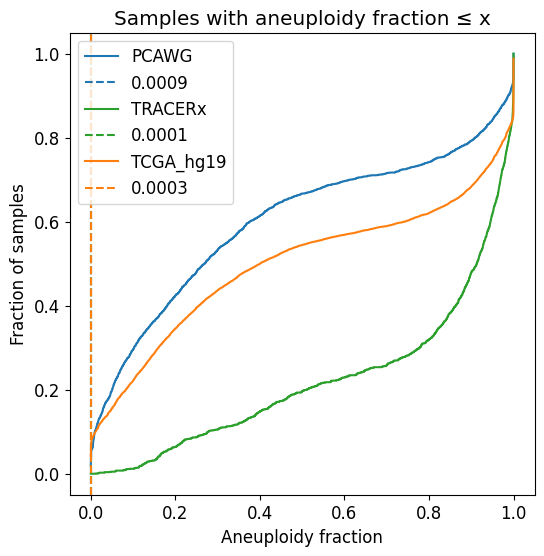

In [27]:
for k in datasets:
    plt.plot(ane_X[k], ane_Y[k], label=k, color=colors[k])    
    knee_index, knee_value = find_knee(ane_X[k], ane_Y[k], knee=True)
    sample_c = ane_Y[k][knee_index] * len(data[k])
    print(k, sample_c, knee_index, knee_value)
    x_pos = ane_X[k][knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{x_pos:.4f}")
    
plt.xlabel("Aneuploidy fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with aneuploidy fraction ≤ x")
plt.savefig(f"{img_path}/fig_samples_imbalance_fraction{file_type}", bbox_inches="tight")

PCAWG 137.0 9 44.257382962528425
TRACERx 0.0 1 0
TCGA_hg19 703.0 3 45.02643770077974


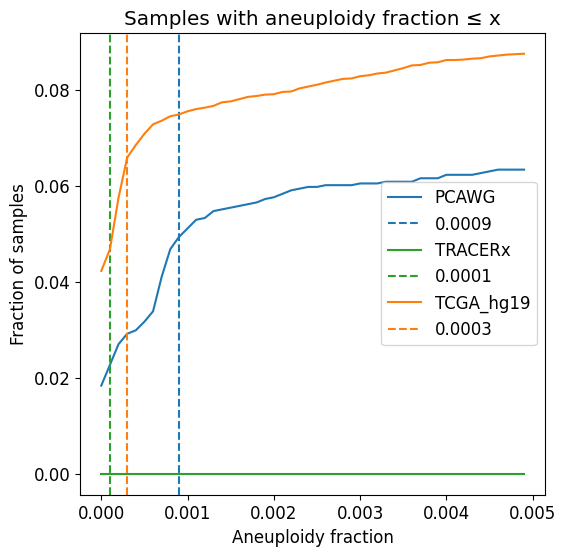

In [28]:
for k in datasets:
    lim = 50
    plt.plot(ane_X[k][:50], ane_Y[k][:50], label=k, color=colors[k])    
    knee_index, knee_value = find_knee(ane_X[k], ane_Y[k], knee=True)
    sample_c = ane_Y[k][knee_index] * len(data[k])
    print(k, sample_c, knee_index, knee_value)
    x_pos = ane_X[k][knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{x_pos:.4f}")
    
plt.xlabel("Aneuploidy fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with aneuploidy fraction ≤ x")
plt.savefig(f"{img_path}/fig_samples_imbalance_fraction{file_type}", bbox_inches="tight")

In [29]:
cov_Y = {}
cov_X = {}
feature = "cover_het_aut"
min_val = 0
for k, v in data.items():
    cov_X[k], cov_Y[k] = count_below_lim(v[feature], min_val=min_val, steps=10000)

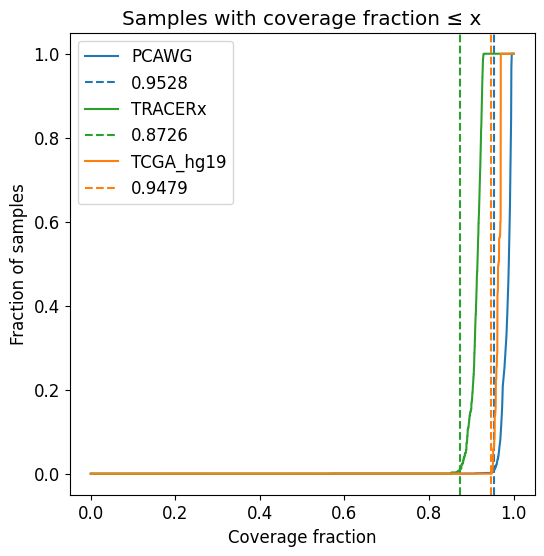

In [30]:
for k in datasets:
    plt.plot(cov_X[k], cov_Y[k], label=k, color=colors[k])        
    knee_index, knee_value = find_knee(cov_X[k],  cov_Y[k], knee=False)
    x_pos = cov_X[k][knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{x_pos:.4f}")

plt.xlabel("Coverage fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with coverage fraction ≤ x")
plt.savefig(f"{img_path}/fig_samples_coverage_fraction{file_type}", bbox_inches="tight")

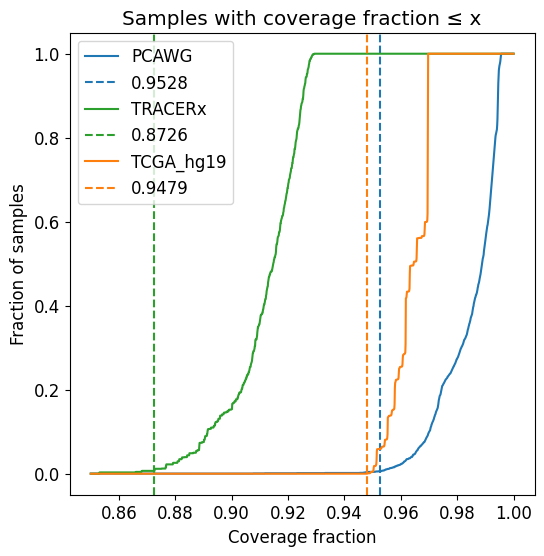

In [31]:
for k in datasets:
    lim = 8500
    plt.plot(cov_X[k][lim:], cov_Y[k][lim:], label=k, color=colors[k])        
    knee_index, knee_value = find_knee(cov_X[k],  cov_Y[k], knee=False)
    x_pos = cov_X[k][knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{x_pos:.4f}")

plt.xlabel("Coverage fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with coverage fraction ≤ x")
plt.savefig(f"{img_path}/fig_samples_coverage_fraction{file_type}", bbox_inches="tight")

In [32]:
break_Y = {}
break_X = {}
break_deltas = {}
feature = "breaks_total_cn_aut"
steps = np.max([np.max(v[feature]) for v in data.values()])
print(steps)
for k, v in data.items():
    break_X[k], break_Y[k] = count_below_lim(v[feature], max_val=steps, steps=steps)

1741


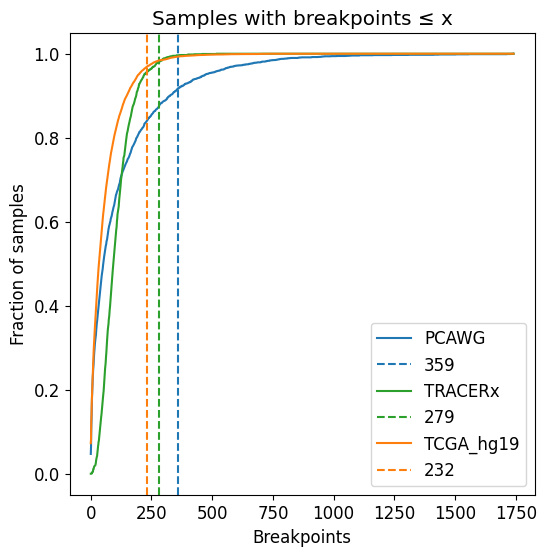

In [33]:
for k in datasets:
    plt.plot(break_X[k], break_Y[k], label=k, color=colors[k])        
    knee_index, knee_value = find_knee(break_X[k], break_Y[k], knee=True)
    x_pos = break_X[k][knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{int(x_pos)}")

plt.ylabel("Fraction of samples")
plt.xlabel("Breakpoints")
plt.title(f"Samples with breakpoints ≤ x")
plt.legend()
plt.savefig(f"{img_path}/fig_samples_breaks_fraction{file_type}", bbox_inches="tight")

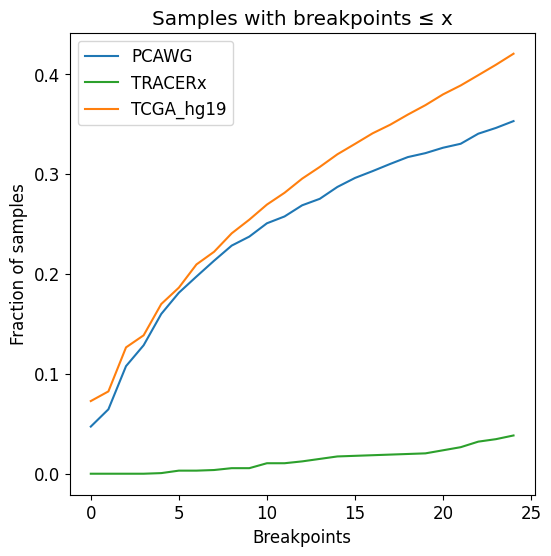

In [34]:
for k in datasets:
    lim = 25
    plt.plot(break_X[k][:lim], break_Y[k][:lim], label=k, color=colors[k])        
    knee_index, knee_value = find_knee(break_X[k], break_Y[k], knee=True)
    x_pos = break_X[k][knee_index]

plt.ylabel("Fraction of samples")
plt.xlabel("Breakpoints")
plt.title(f"Samples with breakpoints ≤ x")
plt.legend()
plt.savefig(f"{img_path}/fig_samples_breaks_fraction{file_type}", bbox_inches="tight")